***
# <font color=green size=10>CURSO DE ESTATÍSTICA - PARTE 1</font>
***

## Trabalho de Análise Descritiva de um Conjunto de Dados

Utilizando os conhecimentos adquiridos em nosso treinamento realize uma análise descritiva básica de um conjunto de dados retirados da Pesquisa Nacional por Amostra de Domicílios - 2015 do IBGE. 

Vamos construir histogramas, calcular e avaliar medidas de tendência central, medidas separatrizes e de dispersão dos dados.

Siga o roteiro proposto e vá completando as células vazias. Procure pensar em mais informações interessantes que podem ser exploradas em nosso dataset.

# <font color=green>DATASET DO PROJETO</font>
***

### Pesquisa Nacional por Amostra de Domicílios - 2015

A <b>Pesquisa Nacional por Amostra de Domicílios - PNAD</b> investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas. O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### Fonte dos Dados

https://ww2.ibge.gov.br/home/estatistica/populacao/trabalhoerendimento/pnad2015/microdados.shtm

### Variáveis utilizadas

> ### Renda
> ***

Rendimento mensal do trabalho principal para pessoas de 10 anos ou mais de idade.

> ### Idade
> ***

Idade do morador na data de referência em anos.

> ### Altura (elaboração própria)
> ***

Altura do morador em metros.

> ### UF
> ***

|Código|Descrição|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo	
> ***

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Anos de Estudo
> ***

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados| 
||Não aplicável|

> ### Cor
> ***

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|
|9|Sem declaração|

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a <b>Renda</b> era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a <b>Renda</b> era missing;
> 3. Foram considerados somente os registros das <b>Pessoas de Referência</b> de cada domicílio (responsável pelo domicílio).

***
***

### Utilize a célula abaixo para importar as biblioteca que precisar para executar as tarefas
#### <font color='red'>Sugestões: pandas, numpy, seaborn</font>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

### Importe o dataset e armazene o conteúdo em uma DataFrame

In [2]:
dados = pd.read_csv('dados.csv')

### Visualize o conteúdo do DataFrame

In [3]:
dados

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
...,...,...,...,...,...,...,...
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344


### Para avaliarmos o comportamento da variável RENDA vamos construir uma tabela de frequências considerando as seguintes classes em salários mínimos (SM)
#### <font color='blue'>Descreva os pontos mais relevantes que você observa na tabela e no gráfico.</font>

Classes de renda:

<b>A</b> ► Acima de 25 SM

<b>B</b> ► De 15 a 25 SM

<b>C</b> ► De 5 a 15 SM

<b>D</b> ► De 2 a 5 SM

<b>E</b> ► Até 2 SM

Para construir as classes de renda considere que o salário mínimo na época da pesquisa era de <b>R$ 788,00</b>.

#### Siga os passos abaixo:

### 1º Definir os intevalos das classes em reais (R$)

In [4]:
renda_Max = dados.Renda.max()
renda_Max= int(renda_Max)

In [5]:
dados.Renda.min()

np.int64(0)

In [6]:
sm = [2,5,15,25]
for i in (sm):
    i = i*788
    print(i)

1576
3940
11820
19700


In [7]:
classes = [0, 1576, 3940, 11820, 19700, renda_Max ]
classes

[0, 1576, 3940, 11820, 19700, 200000]

### 2º Definir os labels das classes

In [8]:
labels = ['E', 'D', 'C', 'B', 'A']

### 3º Construir a coluna de frequências

In [9]:
frequencia = pd.cut(
    x = dados.Renda,        # qual coluna do DataFrame você quer analisar?
    bins = classes,     # quais são os limites das classes?
    labels = labels,   # quais são os nomes das classes?
    include_lowest = True  # inclui o valor mínimo no primeiro intervalo
).value_counts()

frequencia


Renda
E    49755
D    18602
C     7241
B      822
A      420
Name: count, dtype: int64

### 4º Construir a coluna de percentuais

In [10]:
percentual = pd.cut(
    x = dados.Renda,
    bins = classes,
    labels = labels,
    include_lowest = True
).value_counts(normalize=True) * 100

percentual


Renda
E    64.751432
D    24.208745
C     9.423477
B     1.069755
A     0.546590
Name: proportion, dtype: float64

### 5º Juntar as colunas de frequência e percentuais e ordenar as linhas de acordo com os labels das classes

In [11]:
dist_freq_quantitativas_personalizadas = pd.DataFrame(
    {'Frequência': frequencia, 'Porcentagem': percentual}
)
dist_freq_quantitativas_personalizadas

dist_freq_quantitativas_personalizadas.sort_index(ascending=False)


,Frequência,Porcentagem
Renda,,
A,420,0.546590
B,822,1.069755
C,7241,9.423477
D,18602,24.208745
E,49755,64.751432


### Construa um gráfico de barras para visualizar as informações da tabela de frequências acima

<Axes: xlabel='Renda'>

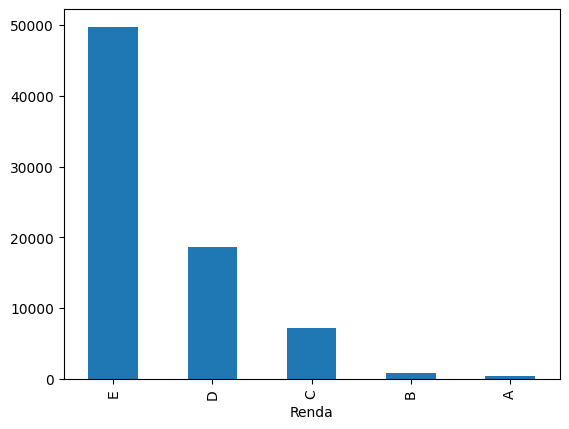

In [12]:
dist_freq_quantitativas_personalizadas['Frequência'].plot.bar()

> ### Conclusões

Escreva suas conclusões aqui...

### Crie um histograma para as variáveis QUANTITATIVAS de nosso dataset
#### <font color='blue'>Descreva os pontos mais relevantes que você observa nos gráficos (assimetrias e seus tipos, possíveis causas para determinados comportamentos etc.)</font>

Text(0.5, 1.0, 'Distribuição de idades')

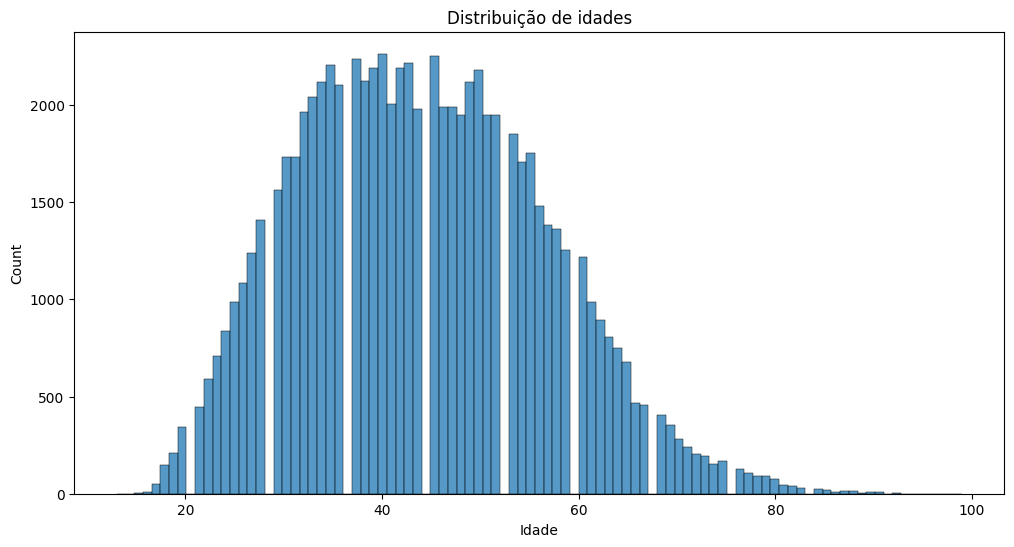

In [13]:
ax = sns.histplot(dados['Idade'])
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de idades')


Text(0.5, 1.0, 'Distribuição de alturas')

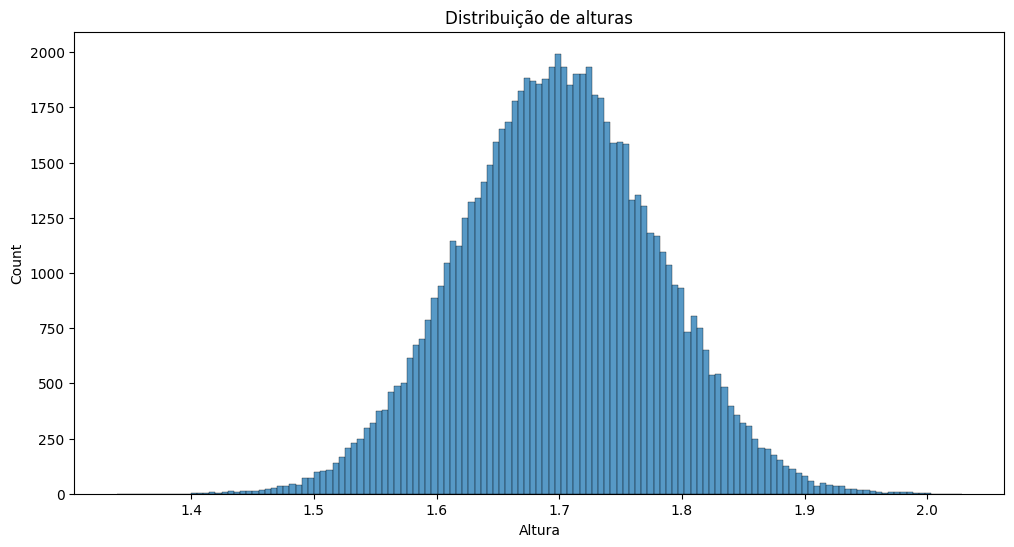

In [14]:
ax = sns.histplot(dados['Altura'])
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de alturas')


Text(0.5, 1.0, 'Distribuição de renda')

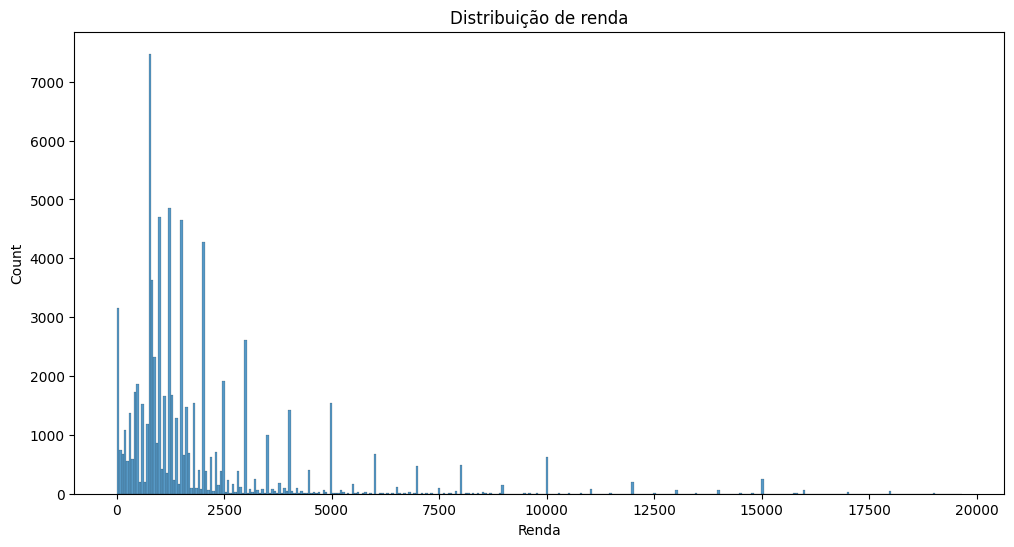

In [15]:
ax = sns.histplot(dados.query('Renda<20000')['Renda'])
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de renda')

Text(0.5, 1.0, 'Distribuição de anos de estudo')

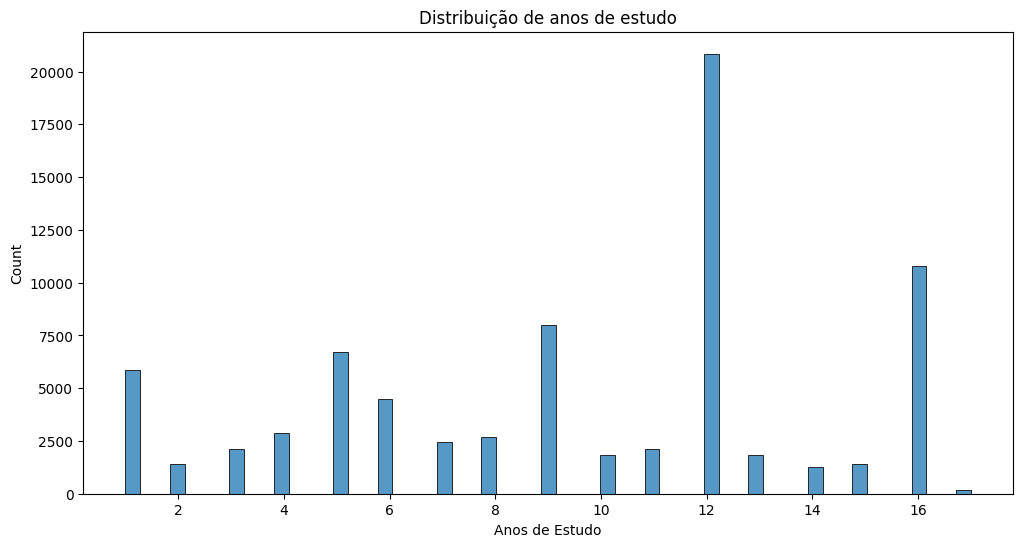

In [16]:
ax = sns.histplot(dados['Anos de Estudo'])
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de anos de estudo')

> ### Conclusões

Escreva suas conclusões aqui...

### Para a variável RENDA, construa um histograma somente com as informações das pessoas com rendimento até R$ 20.000,00

Text(0.5, 1.0, 'Distribuição de renda')

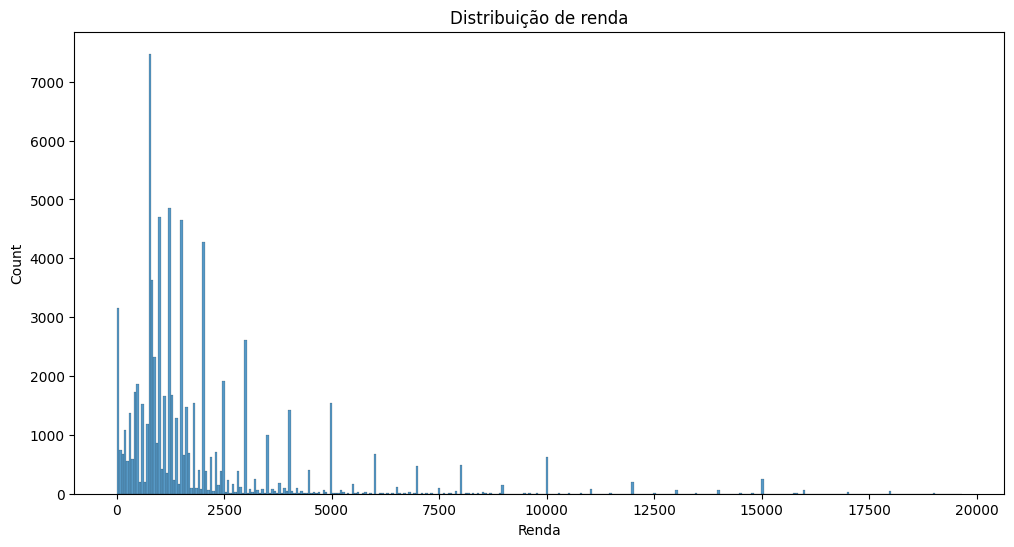

In [17]:
ax = sns.histplot(dados.query('Renda<20000')['Renda'])
ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de renda')

### Construa uma tabela de frequências e uma com os percentuais do cruzando das variáveis SEXO e COR
#### <font color='blue'>Avalie o resultado da tabela e escreva suas principais conclusões</font>
#### <font color='red'>Utilize os dicionários abaixo para renomear as linha e colunas das tabelas de frequências e dos gráficos em nosso projeto</font>

In [18]:
sexo = {
    0: 'Masculino', 
    1: 'Feminino'
}
cor = {
    0: 'Indígena', 
    2: 'Branca', 
    4: 'Preta', 
    6: 'Amarela', 
    8: 'Parda', 
    9: 'Sem declaração'
}
anos_de_estudo = {
    1: 'Sem instrução e menos de 1 ano', 
    2: '1 ano', 
    3: '2 anos', 
    4: '3 anos', 
    5: '4 anos', 
    6: '5 anos', 
    7: '6 anos', 
    8: '7 anos', 
    9: '8 anos', 
    10: '9 anos', 
    11: '10 anos', 
    12: '11 anos', 
    13: '12 anos', 
    14: '13 anos', 
    15: '14 anos', 
    16: '15 anos ou mais', 
    17: 'Não determinados'
}
uf = {
    11: 'Rondônia', 
    12: 'Acre', 
    13: 'Amazonas', 
    14: 'Roraima', 
    15: 'Pará', 
    16: 'Amapá', 
    17: 'Tocantins', 
    21: 'Maranhão', 
    22: 'Piauí', 
    23: 'Ceará', 
    24: 'Rio Grande do Norte', 
    25: 'Paraíba', 
    26: 'Pernambuco', 
    27: 'Alagoas', 
    28: 'Sergipe', 
    29: 'Bahia', 
    31: 'Minas Gerais', 
    32: 'Espírito Santo', 
    33: 'Rio de Janeiro', 
    35: 'São Paulo', 
    41: 'Paraná', 
    42: 'Santa Catarina', 
    43: 'Rio Grande do Sul', 
    50: 'Mato Grosso do Sul', 
    51: 'Mato Grosso', 
    52: 'Goiás', 
    53: 'Distrito Federal'
}

In [19]:
frequencia = pd.crosstab(
    dados.Sexo,
    dados.Cor 
)

frequencia

Cor,0,2,4,6,8
Sexo,,,,,
0,256,22194,5502,235,25063
1,101,9621,2889,117,10862


In [20]:
frequencia.rename(index=sexo, columns=cor, inplace=False)
frequencia


Cor,0,2,4,6,8
Sexo,,,,,
0,256,22194,5502,235,25063
1,101,9621,2889,117,10862


In [21]:
frequencia.rename_axis(None, axis='index', inplace=True)
frequencia.rename_axis(None, axis='columns', inplace=True)


In [22]:
frequencia.rename_axis('Sexo', axis='index', inplace=False)

,0,2,4,6,8
Sexo,,,,,
0,256,22194,5502,235,25063
1,101,9621,2889,117,10862


> ### Conclusões

Escreva suas conclusões aqui...

## Realize, para a variável RENDA, uma análise descritiva com as ferramentas que aprendemos em nosso treinamento

### Obtenha a média aritimética

In [23]:
media = dados.Renda.mean()
media

np.float64(2000.3831988547631)

### Obtenha a mediana

In [24]:
mediana = dados.Renda.median()
mediana

np.float64(1200.0)

### Obtenha a moda

In [25]:
moda = dados.Renda.mode()
moda

0    788
Name: Renda, dtype: int64

### Obtenha o desvio médio absoluto

In [26]:
desvio_medio_absoluto = (dados['Renda'] - dados['Renda'].mean()).abs().mean()
desvio_medio_absoluto


np.float64(1526.4951371638058)

### Obtenha a variância

In [27]:
dados['Renda'].var()

np.float64(11044906.006217021)

### Obtenha o desvio-padrão

In [28]:
dados['Renda'].std()

np.float64(3323.3877303464037)

### Obtenha a média, mediana e valor máximo da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mean', 'median', 'max'}</i></font>

In [29]:
dados_sexo_cor = pd.crosstab(
    dados.Sexo,
    dados.Cor,
    values = dados.Renda,
    aggfunc = ['mean', 'median', 'max']
)

dados_sexo_cor.rename(index=sexo, columns=cor, inplace=True)

dados_sexo_cor




mean                                                      \
Cor           Indígena       Branca        Preta      Amarela        Parda   
Sexo                                                                         
Masculino  1081.710938  2925.744435  1603.861687  4758.251064  1659.577425   
Feminino   2464.386139  2109.866750  1134.596400  3027.341880  1176.758516   

            median                                      max                 \
Cor       Indígena  Branca   Preta Amarela   Parda Indígena  Branca  Preta   
Sexo                                                                         
Masculino    797.5  1700.0  1200.0  2800.0  1200.0    10000  200000  50000   
Feminino     788.0  1200.0   800.0  1500.0   800.0   120000  100000  23000   

                           
Cor       Amarela   Parda  
Sexo                       
Masculino   50000  100000  
Feminino    20000   30000

> ### Conclusões

Escreva suas conclusões aqui...

### Obtenha as medidas de dispersão da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mad', 'var', 'std'}</i></font>

In [30]:
def desvio_medio(x):
    return (x - x.mean()).abs().mean()

dados_disp_sexo_cor = pd.crosstab(
    dados.Sexo,
    dados.Cor,
    values = dados.Renda,
    aggfunc = [desvio_medio, 'var', 'std']
)

dados_disp_sexo_cor.rename(index=sexo, columns=cor, inplace=True)

dados_disp_sexo_cor

desvio_medio                                                     \
Cor           Indígena       Branca       Preta      Amarela        Parda   
Sexo                                                                        
Masculino   798.910889  2261.012346  975.602482  3709.597211  1125.827704   
Feminino   3007.892952  1670.967106  705.453357  2549.146322   811.580946   

                    var                                            \
Cor            Indígena        Branca         Preta       Amarela   
Sexo                                                                
Masculino  1.449841e+06  2.257002e+07  3.749294e+06  3.295707e+07   
Feminino   1.429818e+08  1.056909e+07  1.821960e+06  1.392166e+07   

                                  std                                        \
Cor               Parda      Indígena       Branca        Preta     Amarela   
Sexo                                                                          
Masculino  5.345747e+06   1204.093490  4750.791872  1936.309271  5740.82482   
Feminino   2.547960e+06  11957.498292  3251.013154  1349.799809  3731.17366   

                        
Cor              Parda  
Sexo                    
Masculino  2312.087184  
Feminino   1596.233048

> ### Conclusões

Escreva suas conclusões aqui...

### Construa um box plot da variável RENDA segundo SEXO e COR
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

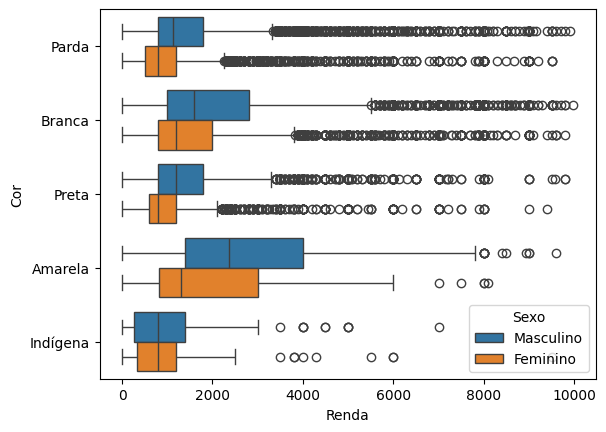

In [31]:
data = dados.query('Renda < 10000').replace({'Cor': cor, 'Sexo': sexo})

ax = sns.boxplot(
    x = 'Renda',
    y = 'Cor',
    hue = 'Sexo',
    data = data,   # <-- usa a variável que você criou!
    orient = 'h'
)


> ### Conclusões

Escreva suas conclusões aqui...

# <font color="red">DESAFIO<font>
### Qual percentual de pessoas de nosso <i>dataset</i> ganham um salário mínimo (R$ 788,00) ou menos?
#### <font color='red'>Utilize a função <i>percentileofscore()</i> do <i>scipy</i> para realizar estas análises.</font>
#### Mais informações: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html


In [34]:
from scipy import stats

stats.percentileofscore(dados.Renda, 788)

np.float64(24.390942217595)

### Qual o valor máximo ganho por 99% das pessoas de nosso <i>dataset</i>?
#### <font color='red'>Utilize o método <i>quantile()</i> do <i>pandas</i> para realizar estas análises.</font>

In [35]:
dados.Renda.quantile(0.99)

np.float64(15000.0)

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = ['mean', 'median', 'max', 'std']</i></font>

In [37]:
dados_estudo_sexo = pd.crosstab(
    dados['Anos de Estudo'],   # linhas = anos de estudo
    dados.Sexo,                # colunas = sexo
    values = dados.Renda,      # calcular sobre a renda
    aggfunc = ['mean', 'median', 'max', 'std']
)

dados_estudo_sexo.rename(index=anos_de_estudo, columns=sexo, inplace=True)
dados_estudo_sexo.round(2)


mean             median           \
Sexo                           Masculino Feminino Masculino Feminino   
Anos de Estudo                                                         
Sem instrução e menos de 1 ano    799.49   516.20     700.0    390.0   
1 ano                             895.63   492.77     788.0    400.0   
2 anos                            931.18   529.91     788.0    450.0   
3 anos                           1109.20   546.85     800.0    500.0   
4 anos                           1302.33   704.28    1000.0    788.0   
5 anos                           1338.65   781.39    1045.0    788.0   
6 anos                           1448.88   833.73    1200.0    788.0   
7 anos                           1465.50   830.75    1200.0    788.0   
8 anos                           1639.40   933.62    1300.0    800.0   
9 anos                           1508.04   868.02    1200.0    788.0   
10 anos                          1731.27   925.92    1218.0    800.0   
11 anos                          2117.06  1286.79    1500.0   1000.0   
12 anos                          2470.33  1682.31    1800.0   1200.0   
13 anos                          3195.10  1911.73    2400.0   1300.0   
14 anos                          3706.62  2226.46    2500.0   1600.0   
15 anos ou mais                  6134.28  3899.51    4000.0   2800.0   
Não determinados                 1295.76   798.17    1200.0    788.0   

                                     max                std           
Sexo                           Masculino Feminino Masculino Feminino  
Anos de Estudo                                                        
Sem instrução e menos de 1 ano     30000    10000   1023.90   639.31  
1 ano                              30000     2000   1331.95   425.29  
2 anos                             40000     4000   1435.17   498.23  
3 anos                             80000     3500   2143.80   424.12  
4 anos                             50000    10000   1419.82   629.55  
5 anos                             35000     8000   1484.65   635.78  
6 anos                             25000     6000   1476.63   574.55  
7 anos                             40000     9000   1419.71   602.04  
8 anos                             30000    18000   1515.58   896.78  
9 anos                             60000    20000   2137.66   973.22  
10 anos                            45000     6000   2078.61   620.61  
11 anos                           200000   100000   2676.54  1819.04  
12 anos                            30000   120000   2268.08  4851.83  
13 anos                            25000    20000   2797.12  2053.79  
14 anos                            50000    20000   3987.21  2064.08  
15 anos ou mais                   200000   100000   7447.61  4212.77  
Não determinados                    7000     3000    979.65   459.99

### Construa um box plot da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Utilize a variável IDADE para identificar se a desigualdade se verifica para pessoas de mesma idade. Exemplo: <i>data=dados.query('Renda < 10000 and Idade == 40')</i> ou <i>data=dados.query('Renda < 10000 and Idade == 50')</i></font>
#### <font color='red'>3º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

Text(0.5, 0, 'R$')

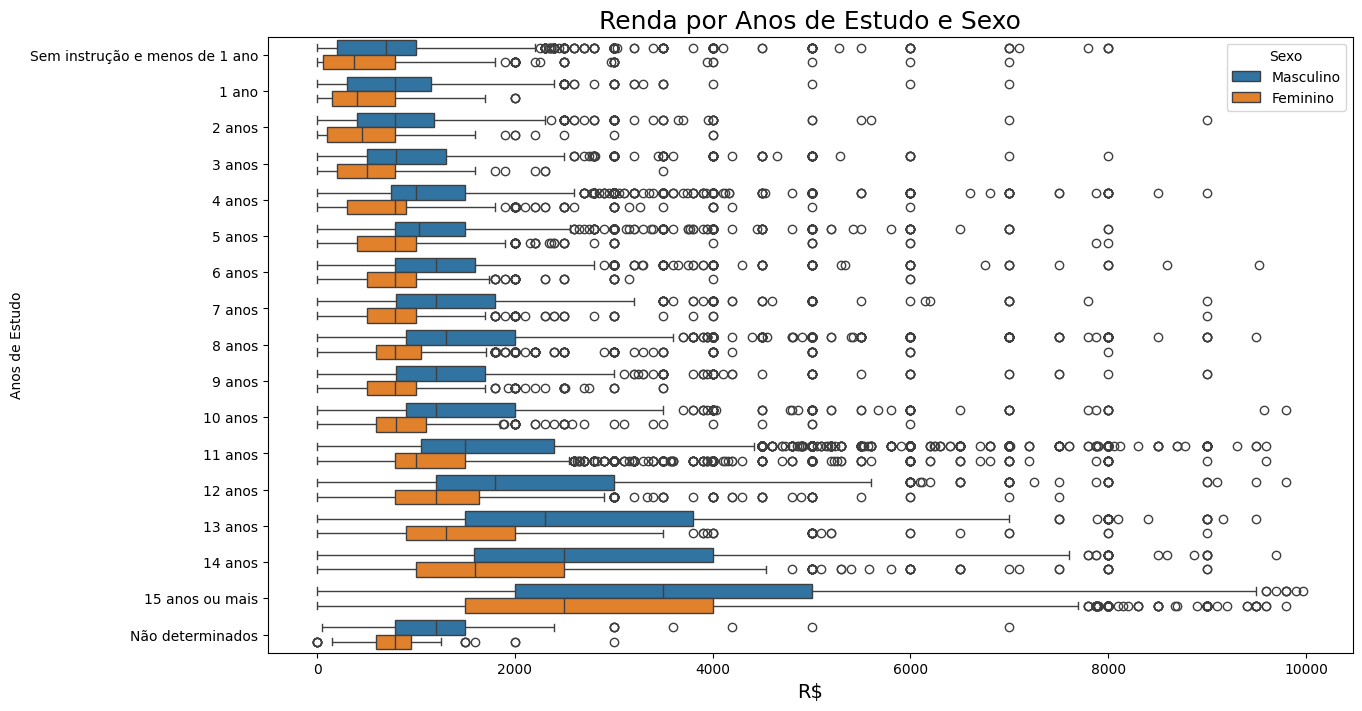

In [41]:
dados_plot = dados.query('Renda < 10000').replace({'Sexo': sexo, 'Anos de Estudo': anos_de_estudo})

ordem = list(anos_de_estudo.values())  # pega os valores do dicionário em ordem

ax = sns.boxplot(
    x = 'Renda',
    y = 'Anos de Estudo',
    hue = 'Sexo',
    data = dados_plot,
    orient = 'h',
    order = ordem   # <-- define a ordem das linhas
)
ax.figure.set_size_inches(14, 8)
ax.set_title('Renda por Anos de Estudo e Sexo', fontsize=18)
ax.set_xlabel('R$', fontsize=14)


Text(0.5, 0, 'R$')

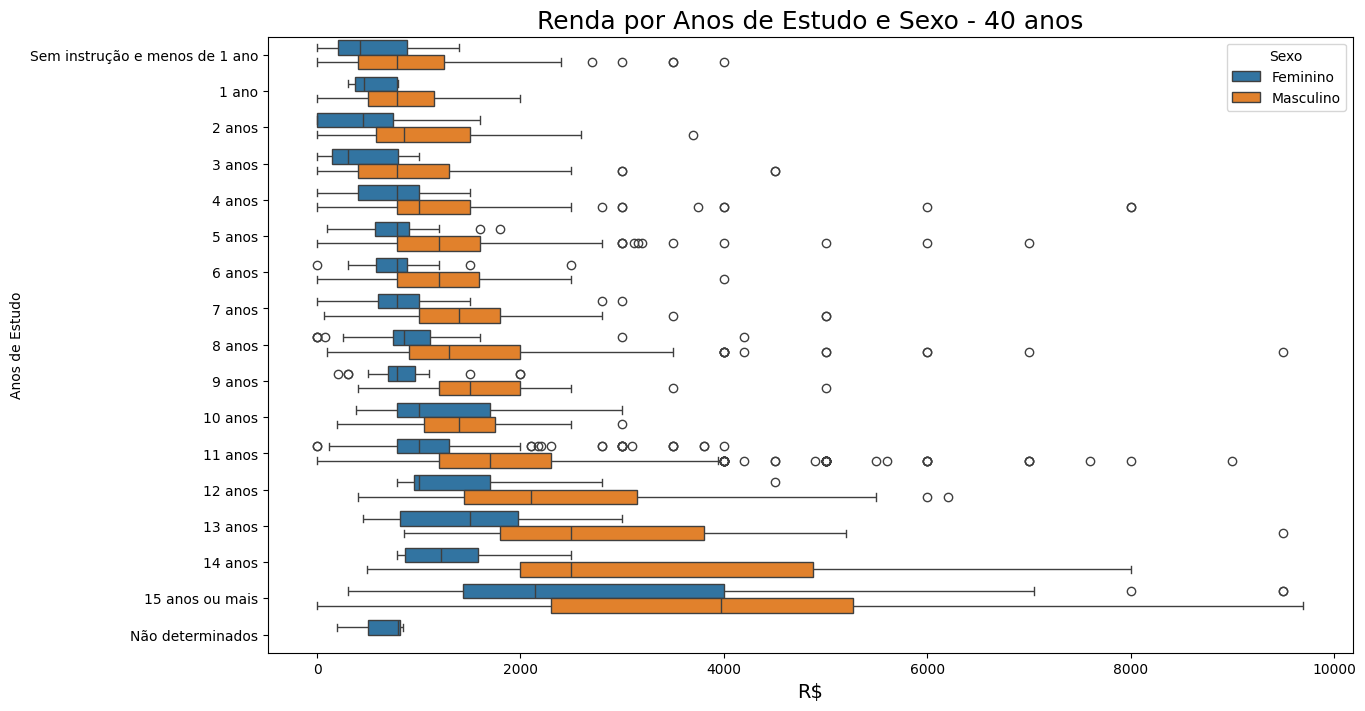

In [43]:
# Gráfico 2 - Filtrando por idade (40 anos)
dados_plot_40 = dados.query('Renda < 10000 and Idade == 40').replace({'Sexo': sexo, 'Anos de Estudo': anos_de_estudo})

ordem = list(anos_de_estudo.values())  # pega os valores do dicionário em ordem

ax = sns.boxplot(
    x = 'Renda',
    y = 'Anos de Estudo',
    hue = 'Sexo',
    data = dados_plot_40,
    orient = 'h',
    order=ordem
)
ax.figure.set_size_inches(14, 8)
ax.set_title('Renda por Anos de Estudo e Sexo - 40 anos', fontsize=18)
ax.set_xlabel('R$', fontsize=14)


> ### Conclusões

Escreva suas conclusões aqui...

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>Utilize o método <i>groupby()</i> do <i>pandas</i> juntamente com o método <i>agg()</i> para contruir a tabulação. O método <i>agg()</i> pode receber um dicionário especificando qual coluna do DataFrame deve ser utilizada e qual lista de funções estatísticas queremos obter, por exemplo: <i>dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})</i></font>

In [45]:
dados_uf = dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})

dados_uf.rename(index=uf, inplace=True)
dados_uf.sort_index(inplace=True)
dados_uf.round(2)


Renda                         
                        mean  median     max      std
UF                                                   
Acre                 1506.09   900.0   30000  2276.23
Alagoas              1144.55   788.0   11000  1237.86
Amapá                1861.35  1200.0   15580  2020.69
Amazonas             1445.13   900.0   22000  1757.94
Bahia                1429.65   800.0  200000  3507.92
Ceará                1255.40   789.0   25000  1821.96
Distrito Federal     4241.95  2000.0  100000  5550.46
Espírito Santo       2026.38  1274.0  100000  3513.85
Goiás                1994.58  1500.0   30000  2221.93
Maranhão             1019.43   700.0   30000  1887.82
Mato Grosso          2130.65  1500.0   35000  2542.63
Mato Grosso do Sul   2262.60  1500.0   42000  3031.42
Minas Gerais         2056.43  1200.0  100000  3584.72
Paraná               2493.87  1500.0  200000  4302.94
Paraíba              1293.37   788.0   30000  1950.27
Pará                 1399.08   850.0   50000  2053.78
Pernambuco           1527.08   900.0   50000  2389.62
Piauí                1074.55   750.0   40000  2373.36
Rio Grande do Norte  1344.72   800.0   15500  1651.81
Rio Grande do Sul    2315.16  1500.0   35000  2913.34
Rio de Janeiro       2496.40  1400.0  200000  5214.58
Rondônia             1789.76  1200.0   50000  2406.16
Roraima              1783.59  1000.0   20000  2079.66
Santa Catarina       2470.85  1800.0   80000  3137.65
Sergipe              1109.11   788.0   16000  1479.00
São Paulo            2638.10  1600.0   80000  3503.78
Tocantins            1771.09  1000.0   60000  2934.59

### Construa um box plot da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>

Text(0.5, 0, 'R$')

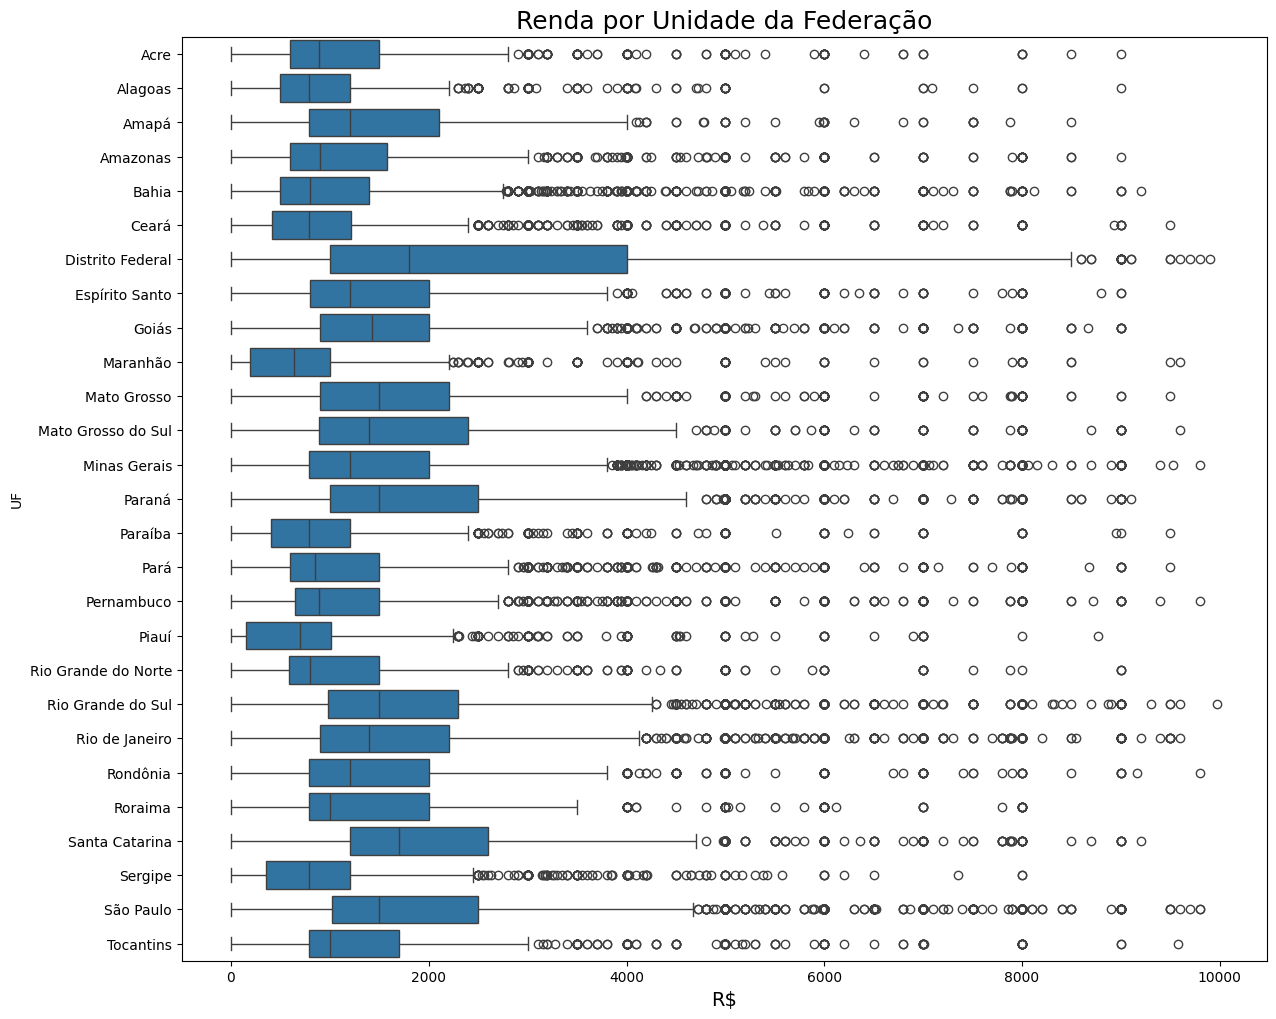

In [46]:
dados_plot = dados.query('Renda < 10000').replace({'UF': uf})

ordem = list(uf.values())

ax = sns.boxplot(
    x = 'Renda',
    y = 'UF',
    data = dados_plot,
    orient = 'h',
    order = sorted(ordem)   # ordena alfabeticamente
)
ax.figure.set_size_inches(14, 12)
ax.set_title('Renda por Unidade da Federação', fontsize=18)
ax.set_xlabel('R$', fontsize=14)


> ### Conclusões

Escreva suas conclusões aqui...